In [4]:
# import SignalRate_2d_osc as s2d
import SignalRate_1d as s1d
import numpy as np
from scipy.optimize import minimize
import definition as df

percision = 64
E_range = (5, 50)
t_range = (0.01, 30)

E_min, E_max = E_range
t_min, t_max = t_range

range_k = [t_range, E_range,  (-1, 1)]

def SR_HK(t, E_e, c, *args):

    R_c, T_c, tau_c, M_a, T_a, tau_a, m_phi, lambda_nu = args

    # N_K = 1.43e32 # for K-II

    N_K = 1.26e34 # for HK

    # eff_K = 0.932/np.sqrt(1+(34/(12-7*E_e+E_e**2))**2)        # This one is not well-fitted

    eff_K = 1

    ret = N_K * s1d.cs_at_c(c, s1d.E_nu(E_e, c)) * s1d.Flux_total(t, s1d.E_nu(E_e, c), R_c, T_c, tau_c, M_a, T_a, tau_a, m_phi, lambda_nu) * s1d.E_nu_at_E_e(E_e, c) * eff_K

    return ret


params = [15, 5, 5, 0.5, 2, 0.6, -4, -12]


def minimize_sr(vars):
    t, E = vars
    return - SR_HK(t, E, 0,*params)

ret = minimize(minimize_sr, x0=[0.1, 10], bounds=(t_range, E_range), method='L-BFGS-B')

print('f_max and coordinates', -ret.fun, ret.x)

f_max = -ret.fun
num_samples = df.gl3_integrate(SR_HK, range_k, percision, args=params)
print('num_samples', num_samples)

def sample_rejection(flux_func, E_range, t_range, f_max, num_samples, *args):
    samples = []
    
    while len(samples) < num_samples:
        # 1. Propose E and t uniformly within your bounds
        E_prop = np.random.uniform(E_range[0], E_range[1])
        t_prop = np.random.uniform(t_range[0], t_range[1])
        
        # 2. Draw a uniform height to test against the flux
        u = np.random.uniform(0, f_max)
        
        # 3. Accept if the test height is under the distribution surface
        if u < flux_func(t_prop, E_prop, 0, *args):
            samples.append((t_prop, E_prop))
            
    return np.array(samples)

t_samples, E_samples = sample_rejection(SR_HK, E_range, t_range, f_max, num_samples, *params).T

np.save(r'F:/Neutrino_SI/Data/samples_HK_1d.npy', np.array([t_samples, E_samples]).T)

f_max and coordinates 102.77173206970421 [1.00000000e-02 1.10282191e+01]
num_samples 2027.3080685339655


KeyboardInterrupt: 

In [ ]:

import SignalRate_1d as s1d
import numpy as np
from scipy.optimize import minimize
import definition as df

percision = 64
E_range = (5, 50)
t_range = (0.01, 30)

E_min, E_max = E_range
t_min, t_max = t_range

t_samples = np.load(r'F:/Neutrino_SI/Data/samples_HK_1d.npy')[:, 0]
E_samples = np.load(r'F:/Neutrino_SI/Data/samples_HK_1d.npy')[:, 1]

print('sample shape', t_samples.shape, E_samples.shape)

range_k = [t_range, E_range,  (-1, 1)]

def SR_HK(t, E_e, c, *args):

    R_c, T_c, tau_c, M_a, T_a, tau_a, m_phi, lambda_nu = args

    # N_K = 1.43e32 # for K-II

    N_K = 1.26e34 # for HK

    # eff_K = 0.932/np.sqrt(1+(34/(12-7*E_e+E_e**2))**2)        # This one is not well-fitted

    eff_K = 1

    ret = N_K * s1d.cs_at_c(c, s1d.E_nu(E_e, c)) * s1d.Flux_total(t, s1d.E_nu(E_e, c), R_c, T_c, tau_c, M_a, T_a, tau_a, m_phi, lambda_nu) * s1d.E_nu_at_E_e(E_e, c) * eff_K

    return ret

def param_set(log_m, log_lambda):
    return [12, 4.5, 4.5, 0.1, 2, 0.5, log_m, log_lambda]

def log_likelihood(log_m, log_lambda):

    fun1_K = lambda x: SR_HK(t_samples, x, 0, *param_set(log_m, log_lambda))

    part1_K = df.gl3_integrate(SR_HK, range_k, percision, args=param_set(log_m, log_lambda))

    part2_K = df.gl_integrate(fun1_K, E_min, E_max)

    part3_K = 0

    ret_K = -part1_K + np.sum(np.log(part3_K + part2_K))

    return ret_K


def chi_2(log_m, log_lambda):
    return -2 * log_likelihood(log_m, log_lambda)

print('baseline:', chi_2(-4, -12))
print(chi_2(1, -5.8))

print(log_likelihood(-4, -12))
print(log_likelihood(1, -5.8))


NameError: name 't_samples' is not defined

In [3]:
import numpy as np
from scipy.optimize import minimize, root_scalar

# 1. Define your mass grid
log_m_vals = np.linspace(0, 3, 50) # 50 points between -1 and 4
log_lambda_95CL = []

for log_m in log_m_vals:
    # --- STEP A: Find the minimum chi_2 (best-fit log_lambda) ---
    # def obj_min(x):
    #     # x is an array, we extract the first element for log_lambda
    #     return chi_2(log_m, x[0])
        
    # # Initial guess for the best fit log_lambda. 
    # # (Adjust -5.0 if your expected coupling scale is vastly different)
    # res_min = minimize(obj_min, x0=[-6.0], method='L-BFGS-B', bounds=[(-10, -3)])
    
    # if not res_min.success:
    #     print(f"Warning: Minimization failed at log_m={log_m}")
    #     log_lambda_95CL.append(np.nan)
    #     continue
        
    # best_log_lambda = res_min.x[0]
    # chi2_min = res_min.fun

    best_log_lambda = -10
    chi2_min = chi_2(1, -10)
    # this is the benchmark of minimum chi_2

    upper_bracket = best_log_lambda + 6  # Adjust if you expect the limit to be higher than this.
    # --- STEP B: Find where Delta chi_2 = 3.84 ---
    target_chi2 = chi2_min + 3.84
    
    def root_func(l_lambda):
        return chi_2(log_m, l_lambda) - target_chi2
        
    try:
        # We are usually looking for the UPPER limit on a coupling.
        # So we search in a bracket starting from the minimum and going higher.
        # (If your limit is expected to be higher than best_log_lambda + 10, increase the upper bracket).
        res_root = root_scalar(root_func, bracket=[best_log_lambda, upper_bracket], method='brentq')
        print('best_log_lambda', best_log_lambda, 'log_m:', log_m, 'log_lambda:', res_root.root)
        log_lambda_95CL.append(res_root.root)
        
    except ValueError:
        # A ValueError usually means the target_chi2 wasn't found inside the bracket.
        print('best_log_lambda', best_log_lambda)
        print(f"Failed to bracket root at log_m = {log_m}. Check the bracket range.")
        log_lambda_95CL.append(np.nan)

# Convert to a numpy array for easy plotting
log_lambda_95CL = np.array(log_lambda_95CL)
print(log_lambda_95CL)

best_log_lambda -10 log_m: 0.0 log_lambda: -5.182370206217859
best_log_lambda -10 log_m: 0.061224489795918366 log_lambda: -5.177481160621068
best_log_lambda -10 log_m: 0.12244897959183673 log_lambda: -5.2010892814189
best_log_lambda -10 log_m: 0.18367346938775508 log_lambda: -5.2162384396671815
best_log_lambda -10 log_m: 0.24489795918367346 log_lambda: -5.216187993002419
best_log_lambda -10 log_m: 0.30612244897959184 log_lambda: -5.262741053239581
best_log_lambda -10 log_m: 0.36734693877551017 log_lambda: -5.283281980157105
best_log_lambda -10 log_m: 0.42857142857142855 log_lambda: -5.317999295876947
best_log_lambda -10 log_m: 0.4897959183673469 log_lambda: -5.340628374048898
best_log_lambda -10 log_m: 0.5510204081632653 log_lambda: -5.354892686771106
best_log_lambda -10 log_m: 0.6122448979591837 log_lambda: -5.379048929858683
best_log_lambda -10 log_m: 0.673469387755102 log_lambda: -5.410149232304778
best_log_lambda -10 log_m: 0.7346938775510203 log_lambda: -5.433638083025457
best_log

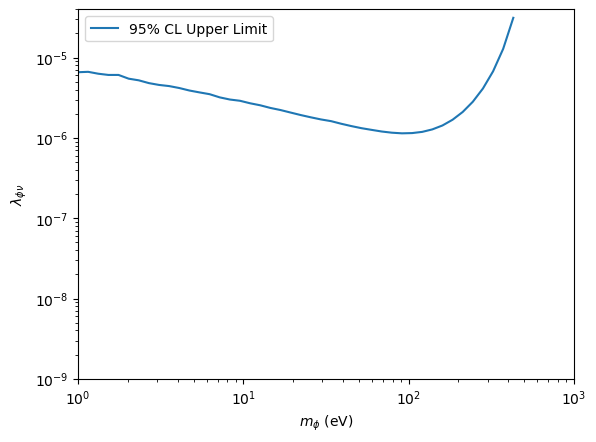

In [ ]:
# save log_m_vals and log_lambda_95CL together to one .npy file
np.save(r'F:/Neutrino_SI/Data/m_lambda_space_1d.npy', np.array([log_m_vals, log_lambda_95CL]).T)
np.load(r'F:/Neutrino_SI/Data/m_lambda_space_1d.npy')  # Load the saved data to verify

log_m_vals, log_lambda_95CL = np.load(r'F:/Neutrino_SI/Data/m_lambda_space_osc_2d.npy').T

%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(10**log_m_vals, 10**log_lambda_95CL, label='95% CL Upper Limit')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m_{\phi}$ (eV)')
ax.set_ylabel(r'$\lambda_{\phi\nu}$')
ax.set_xlim(1, 1e3)
ax.set_ylim(1e-9, 4e-5)
ax.legend()

plt.show()

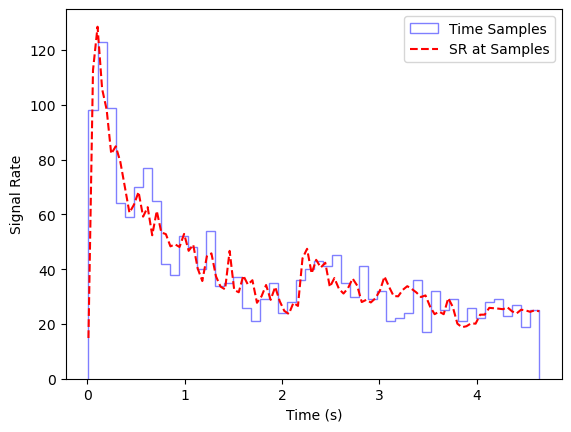

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import definition as df
import SignalRate_2d as s2d
from Simulation_Spectrum import time_limit

t_range = (0.01, time_limit('max'))


t_samples = np.load(r'F:/Neutrino_SI/Data/samples_HK.npy')[:, 0]
E_samples = np.load(r'F:/Neutrino_SI/Data/samples_HK.npy')[:, 1]

def SR_HK(t, E_e, c, *args):

    R_c, T_c, tau_c, M_a, T_a, tau_a, m_phi, lambda_nu = args

    # N_K = 1.43e32 # for K-II

    N_K = 1.26e34 # for HK

    # eff_K = 0.932/np.sqrt(1+(34/(12-7*E_e+E_e**2))**2)        # This one is not well-fitted

    eff_K = 1

    ret = N_K * s2d.cs_at_c(c, s2d.E_nu(E_e, c)) * s2d.flux_2d(t, s2d.E_nu(E_e, c), R_c, T_c, tau_c, M_a, T_a, tau_a, m_phi, lambda_nu) * s2d.E_nu_at_E_e(E_e, c) * eff_K

    return ret

params_1 = [0, 0, 0, 0, 0, 0, -4, -12]
params_2 = [0, 0, 0, 0, 0, 0, 1.2244897959183674, -6.0228186190835595]
ranges: list = [(5, 50),  (-1, 1)]
bin_num = 50

integ_1 = lambda E, c, t: SR_HK(t, E, c, *params_1)
integ_2 = lambda E, c, t: SR_HK(t, E, c, *params_2)

t_space = np.linspace(t_range[0], t_range[1], 100)
y_1 = df.gl2_integrate_vec(integ_1, ranges, t_space)*t_range[1]/bin_num
# y_2 = df.gl2_integrate_vec(integ_2, ranges, t_space)*t_range[1]/bin_num

fig, ax = plt.subplots()
ax.hist(t_samples, bins=bin_num, alpha=0.5, label='Time Samples', color='blue', histtype = 'step')
ax.plot(t_space, y_1, label='SR at Samples', color = 'red', linestyle='--')
# ax.plot(t_space, y_2, label='SR at 95% CL', color = 'green', linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Signal Rate')
plt.legend()

fig